### <img src="./logo_UNSAM.jpg" align="right" width="150" /> 

####  Análisis y Procesamiento de Señales - 1C 2026
# Trabajo Práctico Nº 3: Análisis de Fourier: FFT, desparramo, interpolación y ventaneo
#### Mariano Gonzalez


Se desea analizar un fenómeno muy particular que se da al calcular la DFT, el efecto de desparramo espectral.  

Luego, haremos el siguiente experimento:

Senoidal de frecuencia $f0=k0∗fS/N=k0.Δf$
potencia normalizada, es decir energía (o varianza) unitaria
Se pide:

### $a)$ 

Sea $k0$

- $N4$
 
- $N4+0.25$
 
- $N4+0.5$
 
Notar que a cada senoidal se le agrega una pequeña desintonía respecto a  $Δf$
. Graficar las tres densidades espectrales de potencia (PDS's) y discutir cuál es el efecto de dicha desintonía en el espectro visualizado.

## Generador de Senoidal y variables globales

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft

# Parámetros
fs = 1000        # frecuencia de muestreo
nn = fs          # número de muestras
df=fs/nn
ts=1/fs
eps=1e-12
vmax= np.sqrt(2)

# %%

def mi_funcion_sen( vmax, dc, f0, ph, N, fs):
    tt=np.arange(0,N,1)*(1/fs)
    xx=dc + vmax*np.sin(2*np.pi*f0*tt + ph)
    return tt,xx 

In [2]:
# Definimos las tres frecuencias pedidas

f1 = (nn/4) * df
f2 = (nn/4 + 0.25) * df
f3 = (nn/4 + 0.5) * df

In [3]:
# %%  DFT
tt1, xx1 = mi_funcion_sen( vmax = vmax, dc = 0, f0 = f1, ph=0,N=nn, fs =fs)
tt2, xx2 = mi_funcion_sen( vmax = vmax, dc = 0, f0 = f2, ph=0,N=nn, fs =fs)
tt3, xx3 = mi_funcion_sen( vmax = vmax, dc = 0, f0 = f3, ph=0,N=nn, fs =fs)

XX1 = fft(xx1)
PSD_xx1 = (np.abs(XX1)**2) / (nn**2)

XX2 = fft(xx2)
PSD_xx2 = (np.abs(XX2)**2)/ (nn**2)

XX3 = fft(xx3)
PSD_xx3 = (np.abs(XX3)**2)/ (nn**2)

# Eje de frecuencias en Hertz
freqs = np.arange(nn)
mask = freqs >= 0        # nos quedamos con la parte positiva

### Graficamos y hacemos zoom en la frecuencia de interes, se observa la fuga espectral en la desintonias +0.25 y 0.5

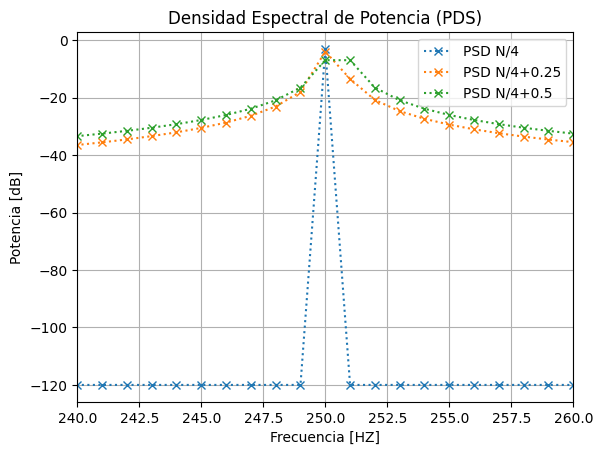

In [4]:
centro = nn/4   # = 125
margen = 10     # bins a cada lado, ajustá a gusto

plt.figure()
plt.clf()
plt.plot(freqs[mask], 10*np.log10(PSD_xx1[mask] + eps), ':x', label="PSD N/4")
plt.plot(freqs[mask], 10*np.log10(PSD_xx2[mask] + eps), ':x', label="PSD N/4+0.25")
plt.plot(freqs[mask], 10*np.log10(PSD_xx3[mask] + eps), ':x', label="PSD N/4+0.5")
plt.xlim(centro - margen, centro + margen)   #  zoom para observar el fenomeno de la desintonia
plt.title("Densidad Espectral de Potencia (PDS)")
plt.xlabel("Frecuencia [HZ]")
plt.ylabel("Potencia [dB]")
plt.legend()
plt.grid(True)
plt.show()

Vemos claramente como en la frecuencia de 250Hz se concentra toda la potencia, ya que la resolucion espectral coincide con un numero entero de bins, vemos que tiene un piso en -120dB, esto es un cero y luego un solo punto en -3dB, la forma de "triangulo" es por la union de los puntos. para $N/4$ + 0.25 y +0.5 desintoniza la resolucion espectral y este deja de caer en un numero entero de bins, esto es la fuga espectral.

### b) 
Verificar la potencia unitaria de cada PSD, puede usar la identidad de Parseval. En base a la teoría estudiada. Discuta la razón por la cual una señal senoidal tiene un espectro tan diferente respecto a otra de muy pocos Hertz de diferencia. 



El Teorema de Parseval establece que la energía (o potencia) se conserva al pasar del dominio temporal al frecuencial: \begin{equation} 
\sum_{n=0}^{N-1} |x[n]|^2 = \frac{1}{N}\sum_{k=0}^{N-1} |X[k]|^2 \end{equation} 

In [8]:
# %% b) parseval

# Parseval: potencia en tiempo = suma de PSD (ambos lados) 
potencia_tiempo_1 = np.mean(xx1**2) # Mean calcula la potencia media de la señal
potencia_parseval_1 = np.sum(PSD_xx1)          # suma toda la PSD (ambos lados)

potencia_tiempo_2 = np.mean(xx2**2)
potencia_parseval_2 = np.sum(PSD_xx2)

potencia_tiempo_3 = np.mean(xx3**2)
potencia_parseval_3 = np.sum(PSD_xx3)

print("               === Verificación de Parseval ===")
print(f"k0 = N/4:      P_tiempo = {potencia_tiempo_1:.6f} | P_Parseval = {potencia_parseval_1:.6f}")
print(f"k0 = N/4+0.25: P_tiempo = {potencia_tiempo_2:.6f} | P_Parseval = {potencia_parseval_2:.6f}")
print(f"k0 = N/4+0.5:  P_tiempo = {potencia_tiempo_3:.6f} | P_Parseval = {potencia_parseval_3:.6f}")

               === Verificación de Parseval ===
k0 = N/4:      P_tiempo = 1.000000 | P_Parseval = 1.000000
k0 = N/4+0.25: P_tiempo = 0.999000 | P_Parseval = 0.999000
k0 = N/4+0.5:  P_tiempo = 1.000000 | P_Parseval = 1.000000


### ¿Por qué el espectro cambia tanto con pocos Hz de diferencia?
La DFT asume implícitamente que la señal es periódica con período exactamente N muestras. Cuando k0 = N/4 exacto:

- La senoidal completa un número entero de ciclos en la ventana, no hay discontinuidad en los bordes entonces la DFT "ve" una senoidal pura, por lo tanto toda la energía cae en un solo bin. Recordando que $Fs/N=Δf$ por bin.

Cuando $k0 = N/4 + 0.25$ o $N/4 + 0.5$:

- La senoidal no completa un ciclo exacto en N muestras, al repetir periódicamente hay una discontinuidad abrupta en los bordes entonces la DFT interpreta esa discontinuidad como contenido en todas las frecuencias, la energía se derrama en otros bins.

### c) 
Repetir el experimento mediante la técnica de zero padding. Dicha técnica consiste en agregar ceros al final de la señal para aumentar $Δf$
 de forma ficticia. Probar agregando un vector de 9*N ceros al final. Discuta los resultados obtenidos.

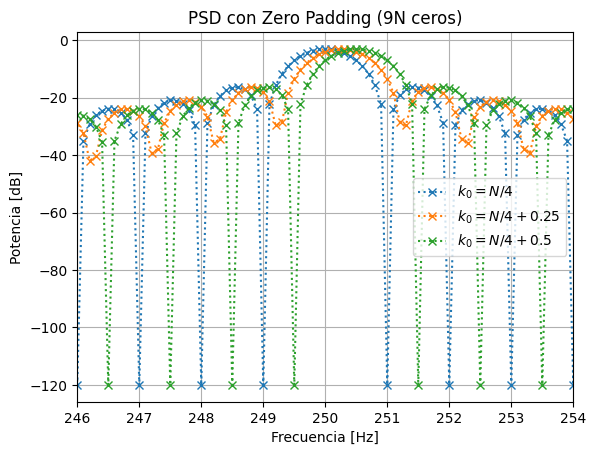

In [10]:
# %% c) 

#Zero padding: agregamos 9*N ceros al final 
N_zp = 9 * nn  # cantidad de ceros
xx1_zp = np.concatenate([xx1, np.zeros(N_zp)])
xx2_zp = np.concatenate([xx2, np.zeros(N_zp)])
xx3_zp = np.concatenate([xx3, np.zeros(N_zp)])

N_total = nn + N_zp # = 10*N

XX1_zp = fft(xx1_zp)
XX2_zp = fft(xx2_zp)
XX3_zp = fft(xx3_zp)

# PSD normalizada por N original (no por N_total)
PSD_xx1_zp = (np.abs(XX1_zp)**2) / (nn**2)
PSD_xx2_zp = (np.abs(XX2_zp)**2) / (nn**2)
PSD_xx3_zp = (np.abs(XX3_zp)**2) / (nn**2)

freqs_zp = np.arange(N_total) * (fs / N_total)
mask_zp = freqs_zp >= 0

centro = f1
margen = 4 # zoom para apreciar mejor el efecto

plt.figure(2)
plt.clf()
plt.plot(freqs_zp[mask_zp], 10*np.log10(PSD_xx1_zp[mask_zp] + eps), ':x', label=r"$k_0 = N/4$")
plt.plot(freqs_zp[mask_zp], 10*np.log10(PSD_xx2_zp[mask_zp] + eps), ':x', label=r"$k_0 = N/4 + 0.25$")
plt.plot(freqs_zp[mask_zp], 10*np.log10(PSD_xx3_zp[mask_zp] + eps), ':x', label=r"$k_0 = N/4 + 0.5$")
plt.xlim(centro - margen, centro + margen)
plt.title("PSD con Zero Padding (9N ceros)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia [dB]")
plt.legend()
plt.grid(True)
plt.show()


- La resolución frecuencial ficticia pasa de $Δf = 1 Hz$ a $Δf' = fs/Ntotal = 0.1 Hz$. No mejora la resolución real, no puede separar dos frecuencias que la ventana original no podía distinguir.
- Esto interpola el espectro, dando más puntos entre bins → las curvas se ven más suaves
- Las tres PSD ahora se ven claramente distintas y separadas, el desparramo sigue presente, pero ahora se ve mejor la forma del lóbulo principal y los lóbulos secundarios